# imports & setup

In [1]:
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt

# scipy

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import DistanceTensorResult
from attention_motifs.features.head_analysis import (
	create_embedding_df_multi,
	plot_head_embeddings_multi,
)
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/")

# load dists

In [3]:
# load head distances
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "features" / "head_dists.zanj"
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
# load attentionpedia
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

[ <ipykernel>:5 ] HEAD_DISTS.distances: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64
[ <ipykernel>:6 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


In [4]:
ATTENTIONPEDIA.type_to_heads().keys()

dict_keys(['IOI:Previous Token', 'IOI:Duplicate Token', 'IOI:Induction', 'IOI:S-Inhibition', 'IOI:Negative Name Mover', 'IOI:Name Mover', 'IOI:Backup Name Mover', 'SAE-survey:Induction', 'SAE-survey:Previous Token', 'SAE-survey:Copy Suppression', 'SAE-survey:Duplicate Token', 'SAE-survey:Successor', 'SAE-survey:Long Range Context Tracking', 'greater-than:YY Identifier', 'greater-than:Static-Year Retriever'])

# head projection & clustering

In [5]:
HEAD_EMBED_DF: pl.DataFrame = create_embedding_df_multi(
	head_dists=HEAD_DISTS,
	attnpedia=ATTENTIONPEDIA,
	embedding_methods=["isomap", "umap", "tsne", "pca"],
	n_components_list=[2],
	n_neighbors_list=[2, 4, 8, 16, 32, 64],
	match_model=None,
	save_path=PATH_BASE / "head_embed",
)

  0%|          | 0/24 [00:00<?, ?it/s]/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
 25%|██▌       | 6/24 [00:07<00:27,  1.53s/it]/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 818 with accuracies 
[1.30754606e-14 5.92483033e-07 9.66245734e-06 4.16613462e-06]
not reaching the requested tolerance 4.470348358154297e-06.
Use iteration 818 instead with accur

Found methods: ['isomap', 'umap', 'tsne']
Found n_neighbors: [2, 4, 8, 16, 32, 64]
Using n_components: 2
Using model: ALL


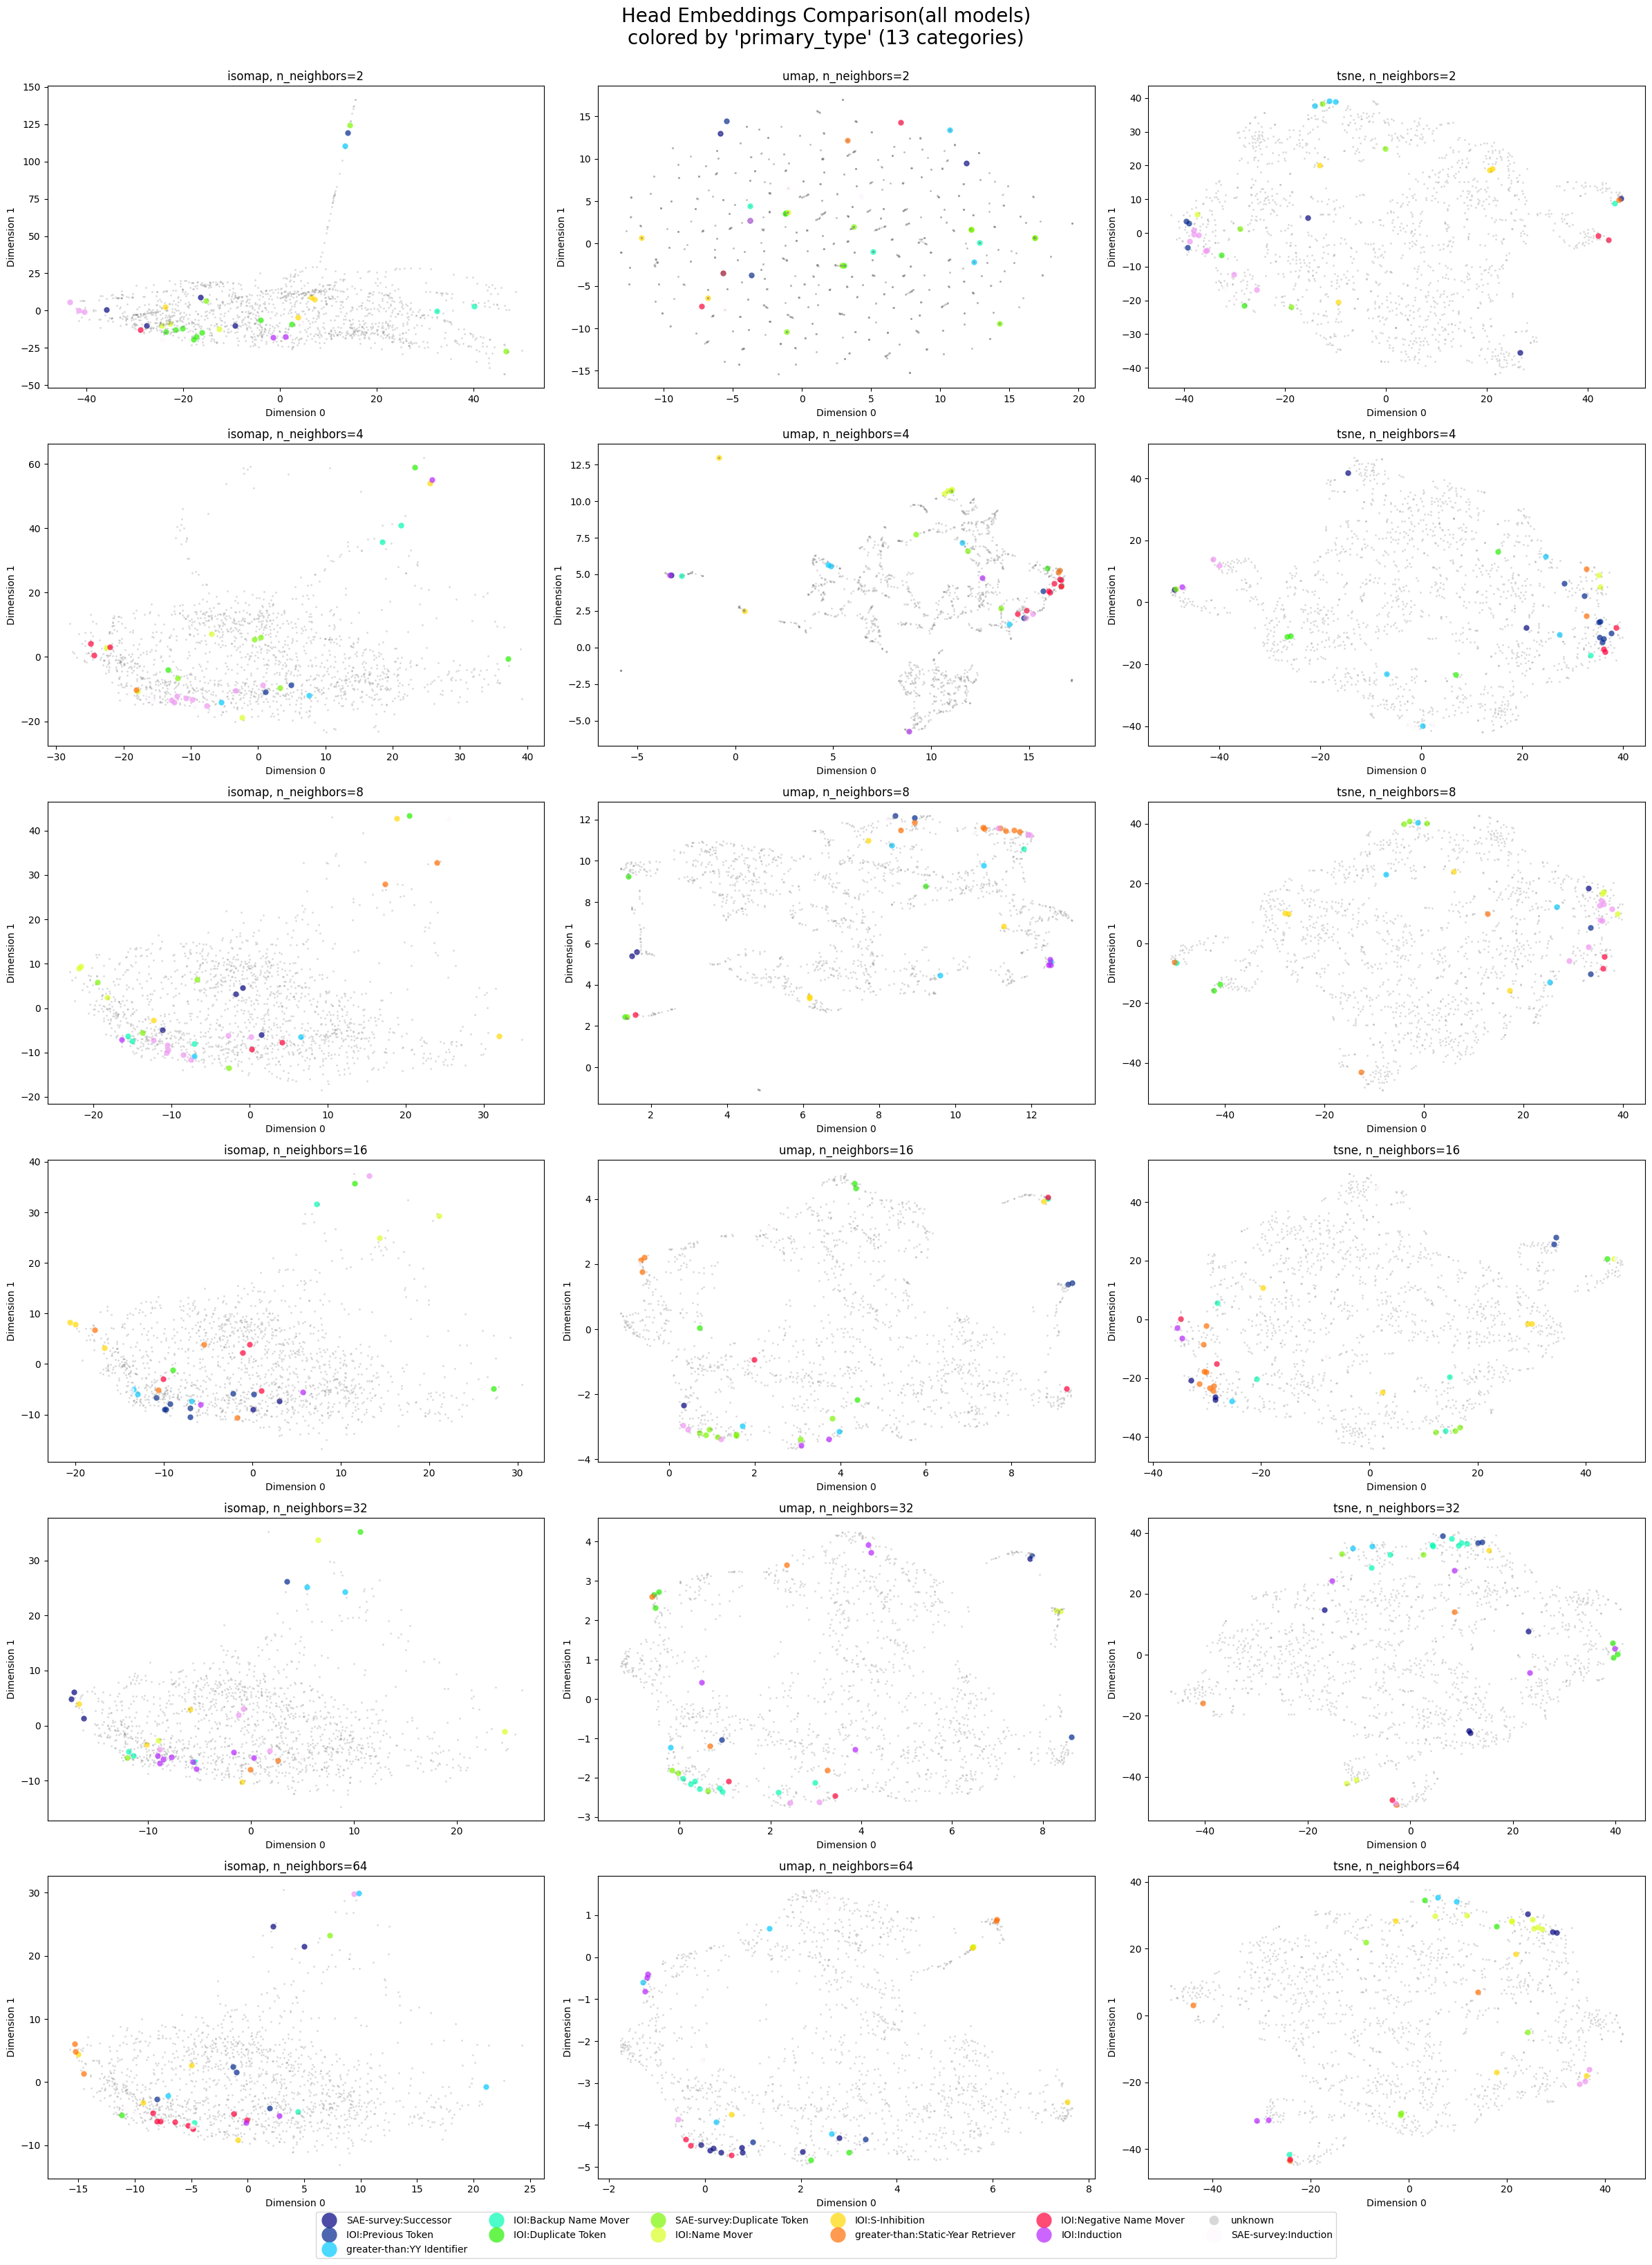

In [9]:
_ = plot_head_embeddings_multi(
	HEAD_EMBED_DF,
	methods=["isomap", "umap", "tsne"],
	sizes=(6, 2),
	figsize=(24, 32),
)
plt.savefig("figures/head_embed.all.pdf", bbox_inches="tight")

In [7]:
HEAD_EMBED_DF_GPT2SMALL: pl.DataFrame = create_embedding_df_multi(
	head_dists=HEAD_DISTS,
	attnpedia=ATTENTIONPEDIA,
	embedding_methods=["isomap", "umap", "tsne", "pca"],
	n_components_list=[2],
	n_neighbors_list=[2, 4, 8, 16, 32, 64],
	match_model="gpt2-small",
	save_path=PATH_BASE / "head_embed",
)

  0%|          | 0/24 [00:00<?, ?it/s]/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
100%|██████████| 24/24 [00:02<00:00, 10.23it/s]


Found methods: ['isomap', 'umap', 'tsne']
Found n_neighbors: [2, 4, 8, 16, 32, 64]
Using n_components: 2
Using model: gpt2-small


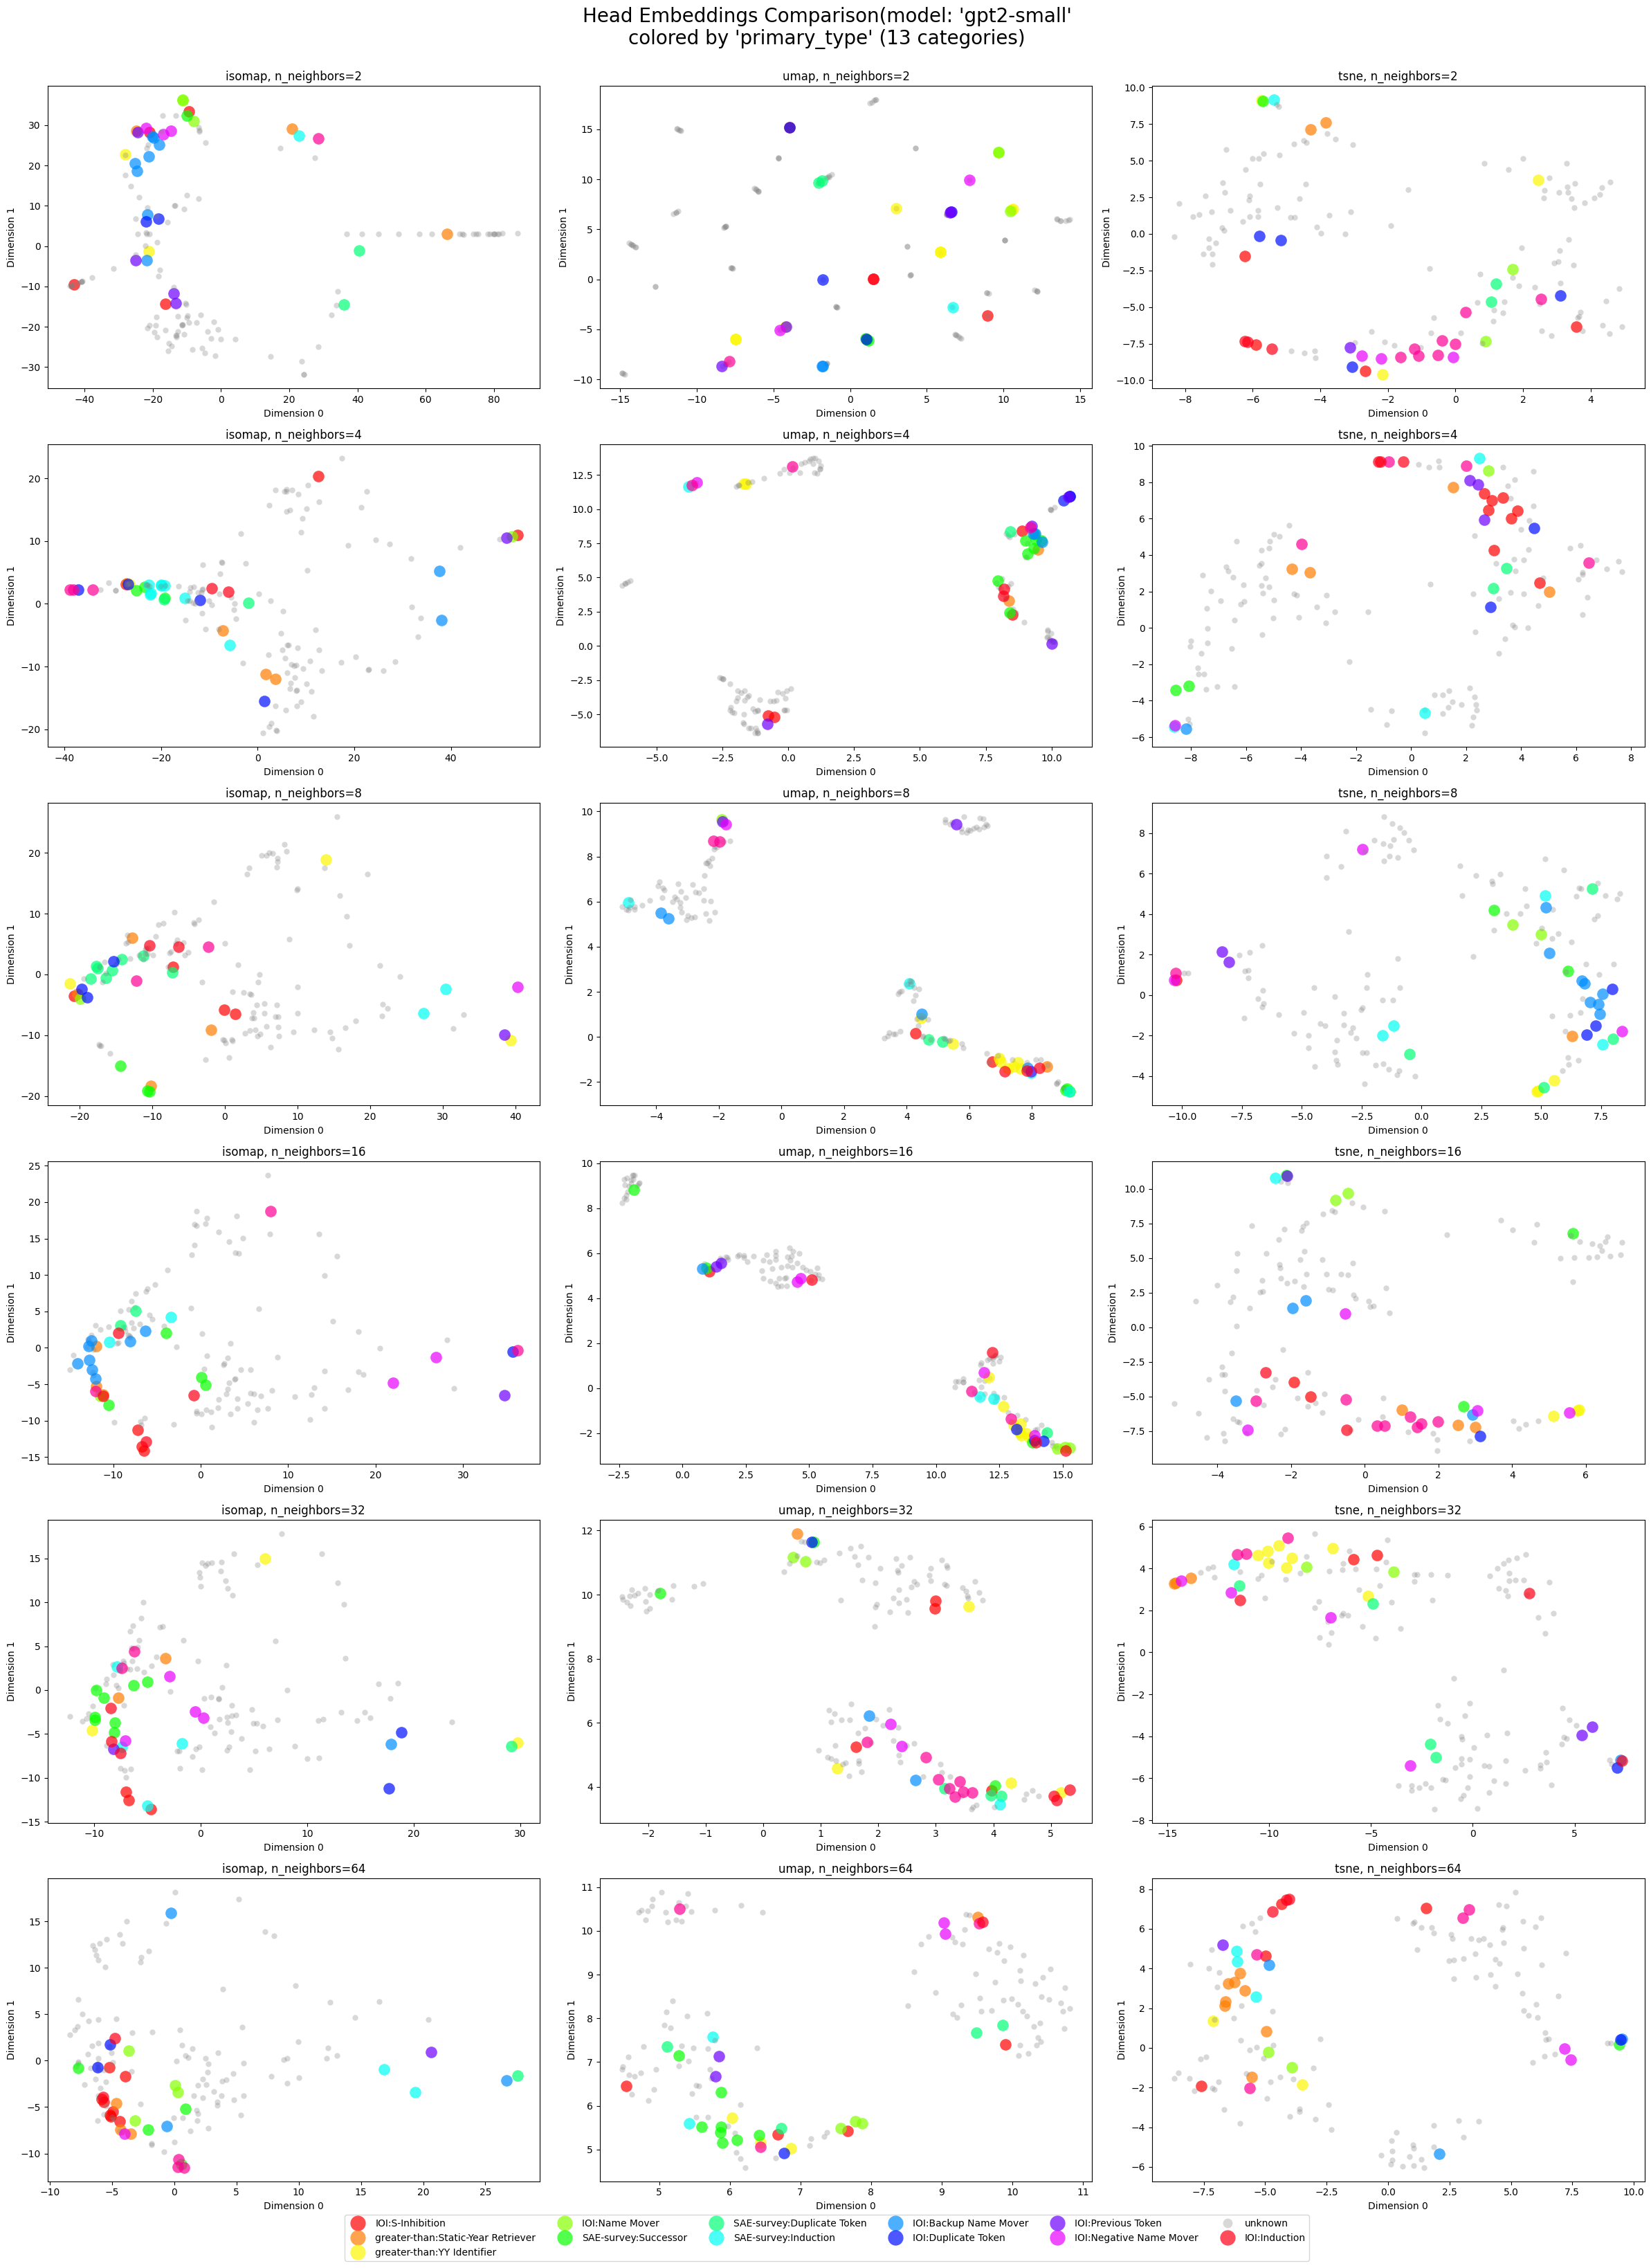

In [8]:
_ = plot_head_embeddings_multi(
	HEAD_EMBED_DF_GPT2SMALL,
	methods=["isomap", "umap", "tsne"],
	sizes=(12, 6),
	figsize=(24, 32),
)
plt.savefig("figures/head_embed.gpt2-small.pdf", bbox_inches="tight")